In [1]:
# Copyright 2023 Nico Curti, Gianluca Carlini, and Riccardo Biondi
# Author: Nico Curti
# e-mail: nico.curti2@unibo.it

In [2]:
import numpy as np
import pylab as plt
import SimpleITK as sitk
from skimage.measure import marching_cubes

from graphomics import LoadImageFileInAnyFormat
from graphomics import ResampleSize
from graphomics import SkeletonizeImageFilter
from graphomics import GraphThicknessImageFilter
from graphomics import EdgeLabelWeightFilter
from graphomics import GraphFilter

# Multi-Modal Image graph

Demo of the `EdgeLabelWeightFilter` applied for the weighing of a skeleton graph according to a multi-modal medical imaging.

In this demo we will see how we can use the skeleton graph using multi-modal images, considering one source for the graph extraction and a second one for its weighing.
In particular we will focus on a classical CT-PET pair, keeping the CT for the anatomical skeleton anaysis and inserting the graph weights according to the value of the PET.

For this demo we will use a 3D CT-PET pair acquired during the [GenoMed4All](https://genomed4all.eu) European project.
GenoMed4All is the European initiative to transform the response to Haematological Diseases by seizing the power of Artificial Intelligence.
One of the data type analyzed along this project involves the Multiple Myeloma case study.
A cohort of patients affected by this disease was collected by the Nuclear Medicine Unit of the Sant'Orsola-Malpighi IRCCS Hospital of the University of Bologna, providing pair of CT-PET of whole patient body.

Multiple Myeloma (MM), also known as plasma cell myeloma and simply myeloma, is a cancer of plasma cells, a type of white blood cell that normally produces antibodies.
Often, no symptoms are noticed initially.
As it progresses, bone pain, anemia, kidney dysfunction, and infections may occur.
Complications may include hypercalcemia and amyloidosis (ref. [Wikipedia](https://en.wikipedia.org/wiki/Multiple_myeloma))

The diagnosis of MM involves the analysis of PET images, paying attention to the signal in proximity to the bone marrows.
For this reason is crucial the correct association between the anatomical information given by the CT scan with the PET ones.

Roughly speaking, the diagnosis could be made considering the PET signal overlayed to the patient skeleton and the abnormalities of this signal could lead to informative features for the patient stratification.
In this context, the possibility to extract and analyze the skeleton skeleton-graph could be informative, but we need to merge also the information given by the PET scan.

In the above example the patient skeleton was obtained by the [Moose](https://github.com/idaholab/moose) algorithm applied on the CT scan.
Different results could be obtained using other kinds of segmentation algorithm.

Given this purpose, the first step is always the display of the starting available information.

In [3]:
ct = LoadImageFileInAnyFormat(filepath='../../../samples/MM/CT.nii.gz')
pet = LoadImageFileInAnyFormat(filepath='../../../samples/MM/PET.nii')
# load also the segmentation obtained by the Moose algorithm
bones = LoadImageFileInAnyFormat(
    filepath='../../../samples/MM/Bones_CT.nii.gz',
    binarize=True
)

print(ct.GetSize(), pet.GetSize(), bones.GetSize())

(512, 512, 237) (128, 128, 237) (512, 512, 237)


As always, the PET scan has a resolution lower than the CT (and related bone segmentation) one.
Starting from this resolution mismatch we could not directly overlay the two image modalities but a registration pre-processing is required.

There are several ways in which we can perform an accurate volume registration, but for the current demo application we will perform just a simple downsampling of the CT/Bones volumes to the same physical space of the PET one.

In [4]:
ct = ResampleSize(
    mask=ct,
    new_size=pet.GetSize(),
    interpolator=sitk.sitkBSpline
)
bones = ResampleSize(
    mask=bones,
    new_size=pet.GetSize(),
    interpolator=sitk.sitkNearestNeighbor
)

print(ct.GetSize(), pet.GetSize(), bones.GetSize())

(128, 128, 237) (128, 128, 237) (128, 128, 237)


Now we can visualize the patient skeleton to check the initial data of our processing.

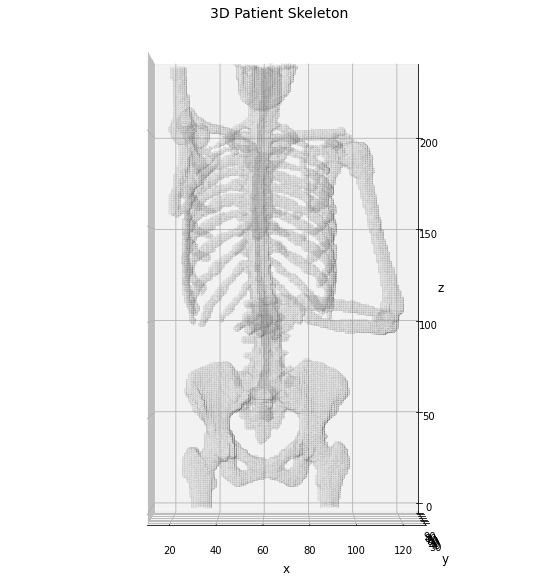

In [5]:
# retro-transform the volume to Numpy fmt for the display
np_bones = sitk.GetArrayFromImage(bones)

# extract the 3D mesh of the object for the plot
verts, faces, normals, values = marching_cubes(np_bones, 0)

# plot the results in a 3D graph
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

# draw the object volume
ptz, pty, ptx = verts.T
ax.plot_trisurf(ptx, pty, faces, ptz, 
                color='lightgray',
                alpha=0.05,
                antialiased=False, 
                linewidth=0.0
               )

ax.set_box_aspect((np.ptp(ptx), np.ptp(pty), np.ptp(ptz)*0.75))
ax.view_init(elev=0., azim=-90)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_zlabel('z', fontsize=12)
_ = ax.set_title('3D Patient Skeleton', fontsize=14)

Now we can use the identified skeleton segmentation as input for the graphomic package, aiming to extract the skeleton graph of the patient skeleton.

In [6]:
# define the skeletonizer to use in the following examples
skeletonizer = SkeletonizeImageFilter()

# apply the skleletonization algorithm
skeletonizer.Execute(bones)
# get the resulting image
skeleton = skeletonizer.GetSkeletonImage()

# define the graph extractor to use in the following examples
extractor = GraphThicknessImageFilter()

# execute the filter
extractor.Execute(skeleton)

# get the computed information about the graph
nodes = extractor.GetNodeIndexes()
edges = extractor.GetEdgeIndexes()
edgeLUT = extractor.GetEdgeLUTIndexes()
edgeMap = extractor.GetEdgeMap()

Display the results for sake of clarity.

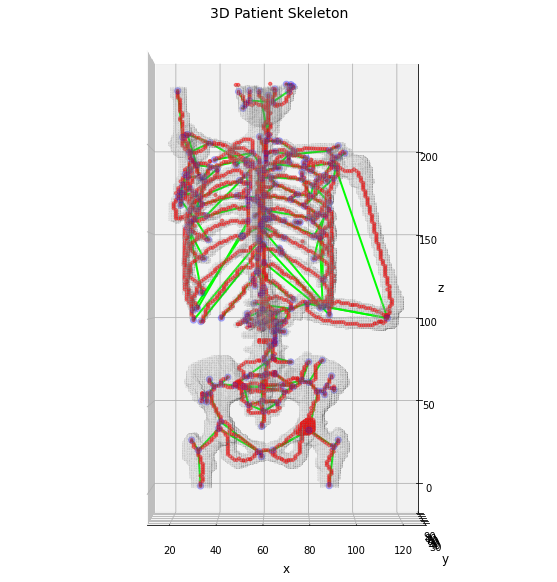

In [7]:
# retro-transform the output to Numpy for the display
np_skeleton = sitk.GetArrayFromImage(skeleton)

# draw the skeleton shape
sz, sy, sx = np.where(np_skeleton)
ax.scatter(sx, sy, sz, color='r', marker='o', s=10, alpha=0.5)

# plot the nodes as blue dots
ax.scatter(*zip(*nodes), color='b', marker='o', s=40, alpha=0.25)
    
# plot the edges as lines between vertices
for ex, ey in edges:
    ax.plot(*zip(*(ex, ey)), color='lime', linewidth=2)
    
fig

Using the skeleton graph we have obtained the graph which describe the anatomical shape of the patient bones, in which each edge should model the series of bone marrow regions.
This skeleton drastically simplify the complexity of the patient skeleton and its analysis could address only anatomical information about the patient.

The still missing information is related to the PET scan, which has not entered yet in the analysis.
To include the PET values we can use the filter provided by the graphomic package weighing the skeleton graph according to the values of the PET scan involved in that segment of the bone.

In [8]:
# declare the weight extractor filter
wtype = EdgeLabelWeightFilter()

# apply the weight extractor to the graph
wtype.Execute(
    nodelist=extractor.GetNodePhysicalPoints(),
    edgelist=extractor.GetEdgePhysicalPoints(),
    lut=extractor.GetEdgeLUTPhysicalPoints(),
    mapper=edgeMap,
    mask=bones,
    labelmap=pet,
    metric='average'
)

# get the computed weights from the filter
weights = wtype.GetWeightsList()

This filter evaluate the "semantic segmentation" of the input skeleton volume, according to the seed points given by the edge labeling.
In this way the resulting weights are evaluated as the average values of the PET signal in proximity of the edges, providing a valuable way to weigh the skeleton graph.

The filter provides in output a simple lookup table of the edge weights, given by a series of pairs (edge-label, edge-weight) in which the edge-label could be related 1-to-1 to the values stored in edgemap.
Using this information we can now weigh our skeleton graph and see how it change accordingly.

In [27]:
# start by copying the edgeMap volume
weighted_skeleton = np.zeros(shape=edgeMap.GetSize(), dtype=np.float32)

# evaluate the connected components of the edgeMap
# for the re-labeling of the edges according to the
# weights estimated by the filter
stats = sitk.LabelShapeStatisticsImageFilter()
stats.SetBackgroundValue(0)
stats.SetGlobalDefaultNumberOfThreads(1)

# evaluate the edgeMap
stats.Execute(edgeMap)

# loop along the label found
for l in stats.GetLabels():
    
    # if it is a component given by an edge
    # aka if it is positive
    if l > 0 and l in weights:

        # get the corresponding list of indices
        idx = stats.GetIndexes(l)

        # reshape to numpy coords
        idx = [idx[i : i + 3]
               for i in range(0, len(idx), 3)
              ]
        idx = np.asarray(idx)

        # get the corresponding weight
        w = weights[l]

        # NOTE: the numpy format is transpose to (z, y, x)
        for z, y, x in idx:
            weighted_skeleton[z, y, x] = w

And now we can visualize the weighted skeleton graph

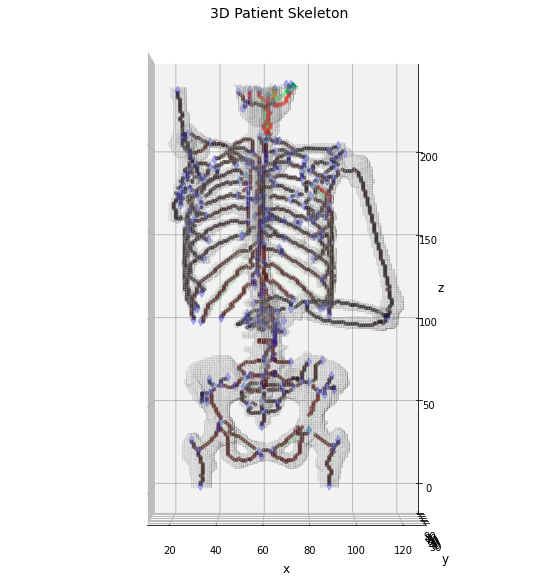

In [48]:
# plot the results in a 3D graph
fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(projection='3d')

# draw the object volume
ptz, pty, ptx = verts.T
ax.plot_trisurf(ptx, pty, faces, ptz, 
                color='lightgray',
                alpha=0.05,
                antialiased=False, 
                linewidth=0.0
               )

ax.set_box_aspect((np.ptp(ptx), np.ptp(pty), np.ptp(ptz)*0.75))
ax.view_init(elev=0., azim=-90)
ax.set_xlabel('x', fontsize=12)
ax.set_ylabel('y', fontsize=12)
ax.set_zlabel('z', fontsize=12)
_ = ax.set_title('3D Patient Skeleton', fontsize=14)

# draw the skeleton shape
sz, sy, sx = np.where(weighted_skeleton)
ax.scatter(sz, sy, sx, c=weighted_skeleton[sz, sy, sx], cmap='hot', marker='o', s=10, alpha=0.5)

# plot the nodes as blue dots
ax.scatter(*zip(*nodes), color='b', marker='d', s=40, alpha=0.25)
    
# normalize the weight for a better visualization
wmax = np.max(list(weights.values()))
    
# plot the edges as lines between vertices
for k, (ex, ey) in edgeLUT.items():
    ax.plot(*zip(*(ex, ey)), color='lime', linewidth=(weights[k]/wmax + 1)*3, alpha=(weights[k]/wmax))

As expected the maximum of the PET signal is found on the patient head, while on the the other bones the links appears quite short.
However, it is interesting to notice how there is a not negligible signal on the back of the patient and in proximity of the heart.
These two areas are particularly interesting for the MM diagnosis and the graphomic features could provide hints about the localization of the most informative areas and the consequent patient stratification.